In [1]:
import scipy.io as sio
import pandas as pd
import numpy as np
import sys, os
import torch
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features
import matplotlib.pyplot as plt

In [2]:
# Load the data
data_2 = sio.loadmat('../data/phase2_data_20220215.mat')
samps_2 = pd.DataFrame(data_2['x'].T)
labs_2  = pd.DataFrame(data_2['y'].T, columns=['y'])

# Combine and drop any NaNs
df_2 = pd.concat([samps_2, labs_2], axis=1)

bad_indices = [
    100,303,496,507,609,706,909,1011,1113,1271,1373,1475,1577,1679,1781,1883,2085,2287,
    2389,2489,2789,2891,2895,2995,3096,3497,3767,3997,4099,4201,4499,4699,5199,5301,
    5302,5500,7688,7690,7691,7692,7696,7702,7704,7708,7715,7723,7727,7810,7841,7870,
    7888,7936,7941,7965,7997,8061,8080,8081,8095,8098,8124,8125,8126,8127,8128,8132,
    8156,8157,8158,8159,8160,8161,8215,8261,8302,8310,8322,8395,8425,8477,8478,8479,
    8483,8487,8491,8496,8527,8563,8587,8642,8743,8848,
    0,94,98,102,203,403,505,607,611,708,809,1009,1111,1171,1273,1473,1575,1579,1635,
    1660,1674,1681,1881,1983,1985,2087,2088,2187,2246,2387,2589,2689,2791,2893,3196,
    3455,3495,3696,3798,3999,4199,4701,4748,4749,4798,4999,5201,5209,5244,5245,5255,
    5924,5945,5977,6128,6135,6229,6271,6299,6377,6383,6388,6389,6678,6760,6903,6906,
    6935,6936,7430,7582,7694,7698,7699,7700,7706,7710,7713,7717,7718,7777,7778,7856,
    7872,7939,7943,7960,7984,7999,8046,8048,8059,8063,8064,8068,8078,8083,8084,8085,
    8093,8165,8166,8191,8308,8366,8397,8398,8481,8485,8489,8493,8494,8498,8544,8565,
    8640,8692,8798,8902
]

df_2 = df_2.drop(index=bad_indices, errors='ignore')
df_2 = df_2.dropna()

shuffled_df = df_2.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]


data_2 = Extract_Features(df_X, df_Y, feature="raw")

# import librosa
# def manipulate(data, sampling_rate=48000, pitch_factor=0.1):
#     return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=pitch_factor)

# # Randomly select 10% of row indices
# num_rows = data_2.get_samples().shape[0]
# frac = 0.1
# selected_idx = np.random.choice(num_rows, size=int(num_rows * frac), replace=False)

# # Apply the function in-place to selected rows
# data_2.X_reduced[selected_idx] = np.array([manipulate(data_2.X_reduced[i]) for i in selected_idx])

print(data_2.get_samples().shape, data_2.get_labels().shape)

(8229, 4800) (8229,)


In [3]:
#display waveform using librosa of a certain index in dataframe
import librosa.display
import matplotlib.pyplot as plt
index_to_display = 0  # Change this to the index you want to display
sample_rate = 48000  # Assuming the sample rate is 48000 Hz
wav = df_2.loc[index_to_display].values[:-1]  # Get the waveform data for the clip
label= df_2.loc[index_to_display].values[-1] # Get the label for the clip
plt.figure(figsize=(10, 4))
librosa.display.waveshow(wav, sr=sample_rate)
plt.title(f'Waveform of Sample {index_to_display}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
#label in plot
plt.text(0, 0.5, f'Label: {label}', fontsize=12, color='red', ha='left', va='center')
plt.show()


KeyError: 0

## Conv Testing

torch.Size([4800])
[INFO] EPOCH: 1/25
Train loss: 0.689802, Train accuracy: 0.5682
[INFO] EPOCH: 2/25
Train loss: 0.622214, Train accuracy: 0.6814
[INFO] EPOCH: 3/25
Train loss: 0.578089, Train accuracy: 0.7299
[INFO] EPOCH: 4/25
Train loss: 0.541955, Train accuracy: 0.7626
[INFO] EPOCH: 5/25
Train loss: 0.531299, Train accuracy: 0.7755
[INFO] EPOCH: 6/25
Train loss: 0.508935, Train accuracy: 0.7947
[INFO] EPOCH: 7/25
Train loss: 0.489834, Train accuracy: 0.8123
[INFO] EPOCH: 8/25
Train loss: 0.462294, Train accuracy: 0.8328
[INFO] EPOCH: 9/25
Train loss: 0.445965, Train accuracy: 0.8447
[INFO] EPOCH: 10/25
Train loss: 0.428990, Train accuracy: 0.8551
[INFO] EPOCH: 11/25
Train loss: 0.415821, Train accuracy: 0.8676
[INFO] EPOCH: 12/25
Train loss: 0.394346, Train accuracy: 0.8832
[INFO] EPOCH: 13/25
Train loss: 0.375695, Train accuracy: 0.9003
[INFO] EPOCH: 14/25
Train loss: 0.359835, Train accuracy: 0.9105
[INFO] EPOCH: 15/25
Train loss: 0.346014, Train accuracy: 0.9232
[INFO] EPOCH: 1

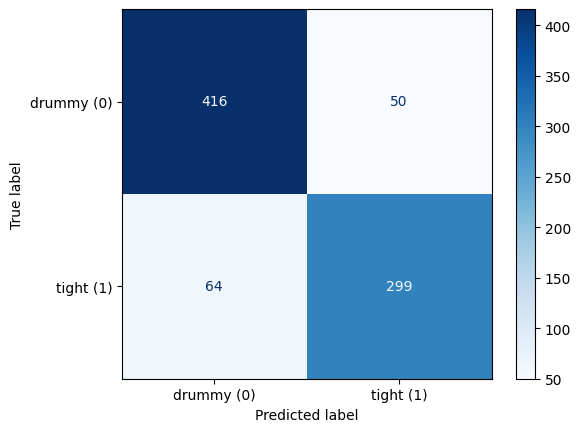


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.87      0.89      0.88       466
   tight (1)       0.86      0.82      0.84       363

    accuracy                           0.86       829
   macro avg       0.86      0.86      0.86       829
weighted avg       0.86      0.86      0.86       829



In [5]:
torch.manual_seed(42)
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 7400))
test_idx = list(range(7400,8229))

train_data = torch.utils.data.Subset(data_2, train_idx)
test_data = torch.utils.data.Subset(data_2, test_idx)

batch_size = 90

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

print(train_loader.dataset[0][0].shape)
epochs = 25
model = models.Convolution_p2()

loops.train(model=model, model_path="./model_paths/raw_p2.pth", train_loader=train_loader,val=False, val_loader=None, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model=model, model_path="./model_paths/raw_p2.pth", test_loader=test_loader, report=True)

## Conv Val and Train

torch.Size([4800])
[INFO] EPOCH: 1/50
Train loss: 0.679266, Train accuracy: 0.5997
Val loss: 0.683418, Val accuracy: 0.6700

[INFO] EPOCH: 2/50
Train loss: 0.616876, Train accuracy: 0.6894
Val loss: 0.635788, Val accuracy: 0.7375

[INFO] EPOCH: 3/50
Train loss: 0.567681, Train accuracy: 0.7397
Val loss: 0.588365, Val accuracy: 0.7575

[INFO] EPOCH: 4/50
Train loss: 0.537767, Train accuracy: 0.7673
Val loss: 0.578736, Val accuracy: 0.7837

[INFO] EPOCH: 5/50
Train loss: 0.520511, Train accuracy: 0.7852
Val loss: 0.584042, Val accuracy: 0.7575

[INFO] EPOCH: 6/50
Train loss: 0.490431, Train accuracy: 0.8071
Val loss: 0.544397, Val accuracy: 0.7963

[INFO] EPOCH: 7/50
Train loss: 0.465146, Train accuracy: 0.8315
Val loss: 0.523592, Val accuracy: 0.8025

[INFO] EPOCH: 8/50
Train loss: 0.445553, Train accuracy: 0.8479
Val loss: 0.523553, Val accuracy: 0.8037

[INFO] EPOCH: 9/50
Train loss: 0.425123, Train accuracy: 0.8633
Val loss: 0.525940, Val accuracy: 0.8087

[INFO] EPOCH: 10/50
Train l

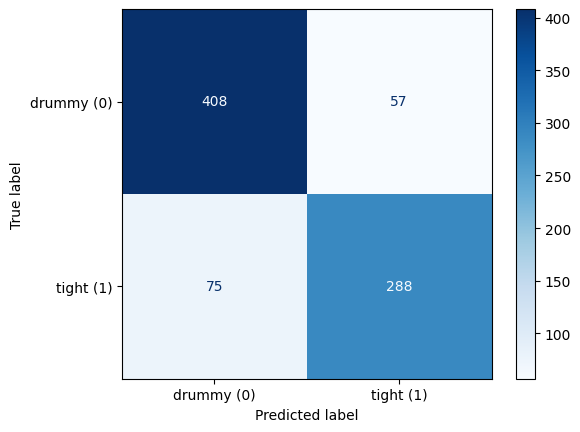


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.84      0.88      0.86       465
   tight (1)       0.83      0.79      0.81       363

    accuracy                           0.84       828
   macro avg       0.84      0.84      0.84       828
weighted avg       0.84      0.84      0.84       828



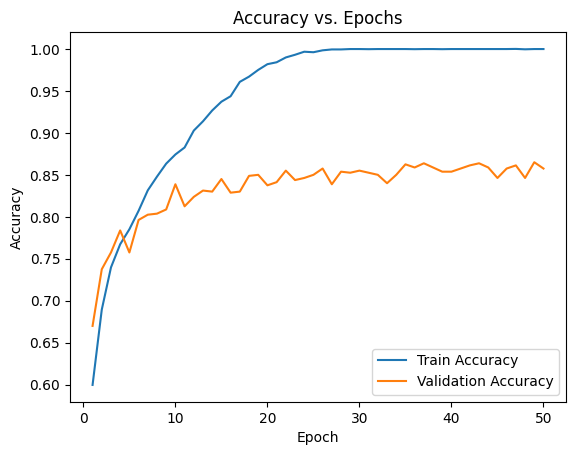

In [3]:
torch.manual_seed(42)
import matplotlib.pyplot as plt
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 6600))
val_idx = list(range(6600,7400))
test_idx = list(range(7400,8228))

train_data = torch.utils.data.Subset(data_2, train_idx)
val_data = torch.utils.data.Subset(data_2, val_idx)
test_data = torch.utils.data.Subset(data_2, test_idx)

batch_size = 90

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

epochs = 50

print(train_loader.dataset[0][0].shape)

model = models.Convolution_p2()

history = loops.train(model=model, model_path="./model_paths/mfcc_p2.pth", train_loader=train_loader,val=True, val_loader=val_loader, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model=model, model_path="./model_paths/mfcc_p2.pth", test_loader=test_loader, report=True)

plt.plot(list(range(1,epochs+1)), history["train_acc"], label="Train Accuracy")
plt.plot(list(range(1,epochs+1)), history["val_acc"],   label="Validation Accuracy")
plt.title("Accuracy vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## BiLSTM

In [8]:
torch.manual_seed(42)
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 7600))
test_idx = list(range(7600,8228))

train_data = torch.utils.data.Subset(data_2, train_idx)
test_data = torch.utils.data.Subset(data_2, test_idx)

batch_size = 90

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

print(train_loader.dataset[0][0].shape)

model = models.ConvBiLSTM(hidden_dim=512, output_dim=2)

loops.train(model=model, model_path="./model_paths/raw_p2.pth", train_loader=train_loader,val=False, val_loader=None, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=30)

loops.test(model=model, model_path="./model_paths/raw_p2.pth", test_loader=test_loader, report=True)

KeyboardInterrupt: 